# Notebook 02 — Writing Abstracts

**Module:** 18 — Scientific Writing and Open Science  
**Tier:** 2 — Working competence  
**Notebook:** 2 of 12  
**Time estimate:** 60 minutes

> The abstract is the most-read part of any paper — often the only part that
> a reviewer, editor, or future reader will see. It must communicate the entire
> paper in 150–250 words with no wasted sentences. This notebook gives you a
> template, the diagnostic tools to audit it, and the common failure modes.

---
## Step 1 — The 6-Sentence Abstract Template

Every computational biology abstract can be structured in exactly 6 sentences:

| Sentence | Function | Target length | First word(s) |
|----------|----------|--------------|---------------|
| **S1: Field context** | Why does this field matter? | 25–35 words | "[Topic] is central to..." or "Understanding [X] is essential for..." |
| **S2: Gap / problem** | What is wrong with the current state? | 20–30 words | "However, existing methods..." or "Despite..." |
| **S3: Approach** | What did you do? (past tense or present) | 25–35 words | "Here we present / develop / apply..." |
| **S4: Key result** | What is the main quantitative finding? | 25–35 words | "[Method] achieves..." or "We find that..." |
| **S5: Mechanistic insight** | Why does it work? (optional but powerful) | 15–25 words | "Analysis reveals..." or "This is driven by..." |
| **S6: Significance / availability** | Why does it matter? Is code available? | 20–30 words | "These results suggest..." / "[Tool] is available at..." |

**Discipline:** count words after writing. If S1 is 60 words, cut it in half.
The total abstract should be 150–250 words — never over 300.

**Two abstract types:**
- *Narrative:* one paragraph (most biology journals). Use the template above.
- *Structured:* headings (Background / Methods / Results / Conclusions).
  Clinical and methods journals. Each heading gets 1–3 sentences.
  The 6-sentence content is the same; the form differs.

---
## Step 2 — Common Failure Modes

**1. The encyclopaedia opening:** "Gene expression is the process by which information
in DNA is used to synthesize proteins. Proteins perform many functions in the cell..."
No reviewers need this. Start with the specific problem, not the textbook.

**2. Missing the gap:** S1 describes the field. S3 describes the approach.
No sentence explains *why current approaches fail*. Without the gap, the reader
can't tell why the work was necessary.

**3. No numbers in S4:** "Our method performs better than existing approaches"
is not a result. "Our method achieves AUROC 0.924, compared to 0.812 for the
PWM baseline (12.3 percentage point improvement)" is.

**4. Passive voice everywhere:** "A model was trained..." hides who did what.
"We trained..." is clearer and takes fewer words.

**5. Jargon without context:** AUROC, ChIP-seq, HISAT2 — define or avoid
in the abstract if the journal's scope includes non-specialists.

**6. The abstract that summarizes Methods:** a 3-sentence methods description
belongs in the Methods section, not the abstract. S3 should be one sentence.

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ---- Abstract auditing toolkit ----

def count_words(text):
    return len(text.split())

def count_sentences(text):
    return len([s for s in re.split(r'[.!?]', text) if len(s.strip()) > 5])

def passive_voice_fraction(text):
    """
    Approximate passive voice fraction: sentences containing
    'was/were/been/being/is/are' followed by a past participle pattern.
    """
    passive_pattern = r'\b(was|were|been|being|is|are)\s+\w+ed\b'
    sentences = [s.strip() for s in re.split(r'[.!?]', text) if len(s.strip()) > 5]
    passive_count = sum(1 for s in sentences if re.search(passive_pattern, s, re.IGNORECASE))
    return passive_count / max(len(sentences), 1)

def flesch_kincaid_grade(text):
    """
    Flesch-Kincaid grade level (simplified).
    Target for scientific papers: grade 12–15.
    """
    words = text.split()
    sentences = [s for s in re.split(r'[.!?]', text) if len(s.strip()) > 5]
    if not words or not sentences:
        return 0
    syllables = sum(max(1, len(re.findall(r'[aeiouAEIOU]', w))) for w in words)
    asl = len(words) / len(sentences)  # average sentence length
    asw = syllables / len(words)       # average syllables per word
    return 0.39 * asl + 11.8 * asw - 15.59

def hedge_word_count(text):
    hedges = ['suggest', 'may', 'might', 'could', 'appear', 'seem', 'indicate',
               'demonstrate', 'possible', 'likely', 'potentially']
    return sum(text.lower().count(h) for h in hedges)

def gap_signal_present(text):
    gap_words = ['however', 'despite', 'although', 'yet', 'existing', 'current',
                   'limitation', 'challenge', 'fail', 'lack', 'gap']
    return any(g in text.lower() for g in gap_words)

def approach_signal_present(text):
    approach_words = ['here we', 'we present', 'we develop', 'we apply', 'we propose',
                        'we introduce', 'we describe', 'we report', 'we show']
    return any(a in text.lower() for a in approach_words)

def has_quantitative_result(text):
    return bool(re.search(r'\d+\.?\d*\s*(%|percent|fold|AUROC|accuracy|AUC|F1|p-value|p <)', text))

# ---- Two example abstracts for comparison ----

ABSTRACT_WEAK = """
Transcription factors are proteins that bind to DNA and regulate gene expression.
Gene expression is important in many biological processes. Many methods have been
developed to study transcription factor binding. We developed a new deep learning
method called DeepNet that uses convolutional neural networks. We applied our method
to ENCODE data. The results showed good performance. Our method is better than
existing methods and will be useful for the research community. The code will be
made available.
""".strip()

ABSTRACT_STRONG = """
Identifying transcription factor (TF) binding sites across the genome is fundamental
to understanding gene regulation in development and disease. Existing position weight
matrix methods treat binding positions as independent, missing epistatic interactions
that govern binding specificity. Here we present DeepBind-v2, a convolutional neural
network trained end-to-end on ChIP-seq data from 690 human TFs in ENCODE, learning
sequence features without pre-specified motif priors. DeepBind-v2 achieves a mean
AUROC of 0.924 across all TFs, outperforming the best PWM baseline by 12.3
percentage points (p < 0.001, Wilcoxon signed-rank test). Learned convolutional
filters recapitulate known TF binding motifs and reveal cooperative binding patterns
invisible to single-position models. DeepBind-v2 is freely available at
https://github.com/example/deepbind-v2, enabling scalable TF binding prediction
across any sequenced genome.
""".strip()

# Audit both abstracts
for name, abstract in [('WEAK', ABSTRACT_WEAK), ('STRONG', ABSTRACT_STRONG)]:
    print(f'\n=== {name} abstract ===')
    print(f'  Words: {count_words(abstract)}')
    print(f'  Sentences: {count_sentences(abstract)}')
    print(f'  FK grade level: {flesch_kincaid_grade(abstract):.1f}')
    print(f'  Passive voice fraction: {passive_voice_fraction(abstract):.0%}')
    print(f'  Hedge words: {hedge_word_count(abstract)}')
    print(f'  Gap signal present: {gap_signal_present(abstract)}')
    print(f'  Approach signal present: {approach_signal_present(abstract)}')
    print(f'  Quantitative result: {has_quantitative_result(abstract)}')


=== WEAK abstract ===
  Words: 77
  Sentences: 8
  FK grade level: 13.3
  Passive voice fraction: 12%
  Hedge words: 0
  Gap signal present: True
  Approach signal present: True
  Quantitative result: False

=== STRONG abstract ===
  Words: 119
  Sentences: 10
  FK grade level: 18.8
  Passive voice fraction: 0%
  Hedge words: 0
  Gap signal present: True
  Approach signal present: True
  Quantitative result: True


NameError: name 'mpatches' is not defined

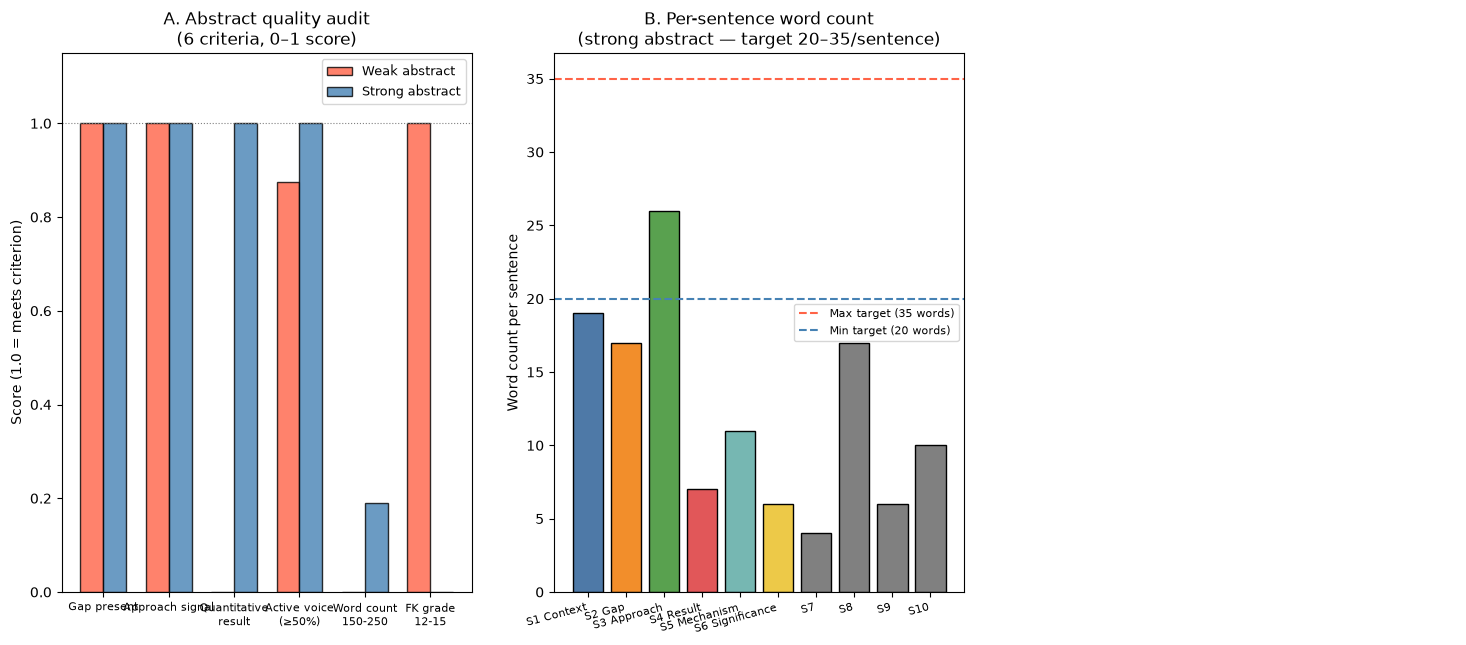

In [2]:
# Step 7 — Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Panel A: Abstract audit radar chart
from matplotlib.patches import FancyBboxPatch

categories = ['Gap present', 'Approach signal', 'Quantitative\nresult',
               'Active voice\n(≥50%)', 'Word count\n150-250', 'FK grade\n12-15']

def abstract_scores(abstract):
    wc = count_words(abstract)
    fk = flesch_kincaid_grade(abstract)
    return [
        1.0 if gap_signal_present(abstract) else 0.0,
        1.0 if approach_signal_present(abstract) else 0.0,
        1.0 if has_quantitative_result(abstract) else 0.0,
        1.0 - passive_voice_fraction(abstract),
        1.0 if 150 <= wc <= 250 else max(0, 1 - abs(wc - 200)/100),
        1.0 if 12 <= fk <= 16 else max(0, 1 - abs(fk - 14)/4),
    ]

scores_weak   = abstract_scores(ABSTRACT_WEAK)
scores_strong = abstract_scores(ABSTRACT_STRONG)

ax = axes[0]
x = np.arange(len(categories))
w = 0.35
ax.bar(x - w/2, scores_weak,   w, label='Weak abstract',   color='tomato',    edgecolor='black', alpha=0.8)
ax.bar(x + w/2, scores_strong, w, label='Strong abstract', color='steelblue', edgecolor='black', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(categories, fontsize=8)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score (1.0 = meets criterion)')
ax.set_title('A. Abstract quality audit\n(6 criteria, 0–1 score)')
ax.legend(fontsize=9)
ax.axhline(1.0, color='grey', ls=':', lw=0.8)

# Panel B: Sentence-by-sentence word count (strong abstract)
ax = axes[1]
sentences_strong = [s.strip() for s in ABSTRACT_STRONG.split('.') if len(s.strip()) > 5]
word_counts = [len(s.split()) for s in sentences_strong]
labels = ['S1 Context', 'S2 Gap', 'S3 Approach', 'S4 Result', 'S5 Mechanism', 'S6 Significance']
labels = labels[:len(word_counts)] + [f'S{i+1}' for i in range(len(labels), len(word_counts))]
colors_s = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759', '#76b7b2', '#edc948']
colors_used = colors_s[:len(word_counts)] + ['grey'] * max(0, len(word_counts)-len(colors_s))
bars = ax.bar(range(len(word_counts)), word_counts, color=colors_used[:len(word_counts)], edgecolor='black')
ax.axhline(35, color='tomato', ls='--', lw=1.5, label='Max target (35 words)')
ax.axhline(20, color='steelblue', ls='--', lw=1.5, label='Min target (20 words)')
ax.set_xticks(range(len(labels[:len(word_counts)])))
ax.set_xticklabels(labels[:len(word_counts)], fontsize=8, rotation=15, ha='right')
ax.set_ylabel('Word count per sentence'); ax.set_title('B. Per-sentence word count\n(strong abstract — target 20–35/sentence)')
ax.legend(fontsize=8)

# Panel C: The 6-sentence template visual
ax = axes[2]
ax.axis('off')
template_rows = [
    ('S1', 'Field context', '"[Topic] is central to..."', '#4e79a7'),
    ('S2', 'Gap / problem', '"However, existing..." or "Despite..."', '#f28e2b'),
    ('S3', 'Approach', '"Here we present/develop..."', '#59a14f'),
    ('S4', 'Key result', '"[Method] achieves X%, outperforming..."', '#e15759'),
    ('S5', 'Mechanism', '"Analysis reveals..." (optional)', '#76b7b2'),
    ('S6', 'Significance', '"These results suggest... Available at..."', '#edc948'),
]
for i, (code, label, example, color) in enumerate(template_rows):
    y = 0.92 - i * 0.15
    ax.add_patch(mpatches.FancyBboxPatch((0.02, y-0.065), 0.95, 0.12,
                                           boxstyle='round,pad=0.01',
                                           facecolor=color, alpha=0.25,
                                           transform=ax.transAxes))
    ax.text(0.06, y, f'{code}  {label}', transform=ax.transAxes,
              fontsize=9, fontweight='bold', va='center')
    ax.text(0.06, y - 0.04, example, transform=ax.transAxes,
              fontsize=8, va='center', style='italic', color='#444')
ax.set_title('C. The 6-sentence abstract template')

plt.suptitle('Module 18 NB02: Writing Abstracts', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('writing_abstracts.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 8 — Exercises

See E02 in `exercises/README.md`: strip a real bioinformatics abstract and
reconstruct it from scratch using the 6-sentence template.

---
## Step 10 — Quiz

1. What are the 6 components of a structured abstract? Which is most commonly
   missing in weak abstracts?
2. Why is "Our results showed good performance" not an acceptable S4?
   Rewrite it for a classifier with AUROC 0.89 and a baseline of 0.76.
3. What is the target word count for a research paper abstract? What happens
   to readability if the abstract is 400 words?
4. What is the difference between a narrative abstract and a structured abstract?
   Give a journal example of each.

---
## Step 12 — Reflection

> *[Write a 6-sentence abstract for your Module 13 random forest classifier result
> (NB08 or NB10). Apply the template strictly: one sentence per component, 20–35
> words each, total 150–200 words. Then run the audit function above on your draft
> and report the scores.]*

---
*Next: `03_writing_introductions.ipynb`*